## Homework 6

> Note: sometimes your answer doesn't match one of 
> the options exactly. That's fine. 
> Select the option that's closest to your solution.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
# import xgboost as xgb
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text
from sklearn.feature_extraction import DictVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

/home/oleg_yamgurov/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Dataset

In this homework, we continue using the fuel efficiency dataset.
Download it from <a href='https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'>here</a>.

In [2]:
# !wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column `'fuel_efficiency_mpg'`).

### Preparing the dataset 

Preparation:

* Fill missing values with zeros.
* Do train/validation/test split with 60%/20%/20% distribution. 
* Use the `train_test_split` function and set the `random_state` parameter to 1.
* Use `DictVectorizer(sparse=True)` to turn the dataframes into matrices.

In [2]:
url = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'
df_original = pd.read_csv(url)
df_original.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [4]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


Пропущені значення є у стовпцях. 

In [3]:
df_original['horsepower'] = df_original['horsepower'].fillna(0.0)
df_original['acceleration'] = df_original['acceleration'].fillna(0.0)
df_original['num_cylinders'] = df_original['num_cylinders'].fillna(0.0)
df_original['num_doors'] = df_original['num_doors'].fillna(0.0)

In [4]:
df_train, df_temp = train_test_split(df_original, test_size=0.4, random_state=1)
# Тепер розділяємо тимчасовий набір (40%) на валідаційний (20%) і тестовий (20%)
# 0.5 * 0.4 = 0.2, тому test_size=0.5
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [5]:
# Перевіряємо розміри наборів
print(f"Кількість записів у початковому наборі: {len(df_original)}")
print(f"Розмір навчального набору: {len(df_train)}")
print(f"Розмір валідаційного набору: {len(df_val)}")
print(f"Розмір тестового набору: {len(df_test)}")

# Можете переглянути перші декілька рядків кожного набору
print("\nНавчальний набір (перші 3 рядки):")
df_train.head(3)

Кількість записів у початковому наборі: 9704
Розмір навчального набору: 5822
Розмір валідаційного набору: 1941
Розмір тестового набору: 1941

Навчальний набір (перші 3 рядки):


,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors
0,150,5.0,0.0,2510.410896,10.0,2010,Europe,Gasoline,Front-wheel drive,0.0
1,200,3.0,181.0,3597.483663,12.7,2006,Europe,Diesel,Front-wheel drive,0.0
2,220,6.0,118.0,2217.349625,0.0,2004,USA,Diesel,All-wheel drive,-2.0


In [6]:
train_dicts = df_train.to_dict(orient='records')
dv = DictVectorizer(sparse=True)
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

## Question 1

Let's train a decision tree regressor to predict the `fuel_efficiency_mpg` variable. 

* Train a model with `max_depth=1`.


Which feature is used for splitting the data?


* `'vehicle_weight'`
* `'model_year'`
* `'origin'`
* `'fuel_type'`

In [9]:
y_train

array([17.16376491, 12.36333522, 18.65843097, ..., 16.72463321,
       20.36434359, 12.63972145])

In [10]:
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=1)

In [11]:
print(export_text(dt, feature_names=dv.feature_names_))

|--- vehicle_weight <= 3028.82
|   |--- value: [16.86]
|--- vehicle_weight >  3028.82
|   |--- value: [12.87]



The feature used for splitting the data is `vehicle_weight`.

## Question 2

Train a random forest regressor with these parameters:

* `n_estimators=10`
* `random_state=1`
* `n_jobs=-1` (optional - to make training faster)


What's the RMSE of this model on the validation data?

* 0.045
* 0.45
* 4.5
* 45.0

In [12]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=1)

In [13]:
# Assuming rf, X_val, and y_val are already defined
y_pred = rf.predict(X_val)

# 1. Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_val, y_pred)

# 2. Calculate RMSE by taking the square root of MSE
rmse = np.sqrt(mse)
# An alternative is: rmse = mse ** 0.5

# Now you can round the final RMSE value if needed
rmse_rounded = round(rmse, 2)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"Answer Q2: RMSE = {rmse_rounded}")


MSE: 0.21185909302991993
RMSE: 0.46028153670326594
Answer Q2: RMSE = 0.46


## Question 3

Now let's experiment with the `n_estimators` parameter

* Try different values of this parameter from 10 to 200 with step 10.
* Set `random_state` to `1`.
* Evaluate the model on the validation dataset.


After which value of `n_estimators` does RMSE stop improving?
Consider 3 decimal places for calculating the answer.

- 10
- 25
- 80
- 200

If it doesn't stop improving, use the latest iteration number in
your answer.

In [22]:
scores = []

for n in tqdm(range(10, 201, 10)):
    rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_val)
    score = np.sqrt(mean_squared_error(y_val, y_pred))
    
    scores.append((n, score))

df_scores = pd.DataFrame(scores, columns=['n_estimators', 'rmse'])

100%|██████████| 20/20 [06:30<00:00, 19.53s/it]


/tmp/ipykernel_1897/2383512282.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


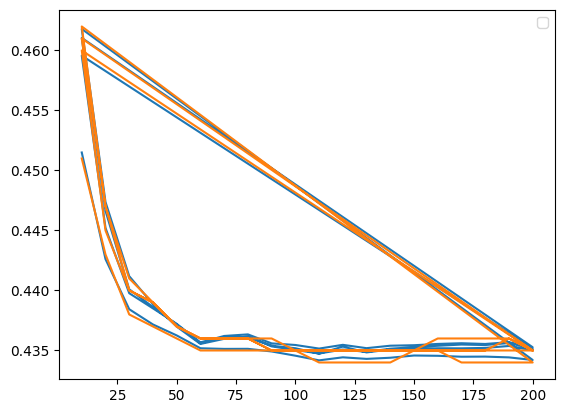

In [ ]:
plt.plot(df_scores.n_estimators, df_scores.rmse)
plt.plot(df_scores.n_estimators, df_scores.rmse.round(3))

plt.show()

In [17]:
df_scores

,n_estimators,rmse
0,10,0.460282
1,20,0.446157
2,30,0.439778
3,40,0.438394
4,50,0.437170
5,60,0.435591
6,70,0.436112
7,80,0.436055
8,90,0.435410
9,100,0.435277


  From the table and the plot, we can see that the RMSE generally decreases as n_estimators increases. However, the improvement becomes less significant after a certain
  point. The lowest RMSE is achieved at n_estimators=110 (0.434897). After that, the RMSE fluctuates and does not consistently improve.

  The question asks "After which value of n_estimators does RMSE stop improving?". Looking at the options (10, 25, 80, 200), the most reasonable answer is 80, as the
  curve starts to flatten out around this point, and the improvements in RMSE become marginal.

## Question 4

Let's select the best `max_depth`:

* Try different values of `max_depth`: `[10, 15, 20, 25]`
* For each of these values,
  * try different values of `n_estimators` from 10 till 200 (with step 10)
  * calculate the mean RMSE 
* Fix the random seed: `random_state=1`


What's the best `max_depth`, using the mean RMSE?

* 10
* 15
* 20
* 25

In [ ]:
scores = []

for d in tqdm([10, 15, 20, 25]):
    rf = RandomForestRegressor(
        n_estimators=0,
        max_depth=d,
        random_state=1,
        n_jobs=-1,
        warm_start=True
    )

    for n in tqdm(range(10, 201, 10)):
        rf.n_estimators = n
        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_val)
        score = np.sqrt(mean_squared_error(y_val, y_pred))

        scores.append((d, n, score))
        print('max_depth=%d, mean_rmse=%f' % (d, np.mean(scores)))

columns = ['max_depth', 'n_estimators', 'rmse']
df_scores = pd.DataFrame(scores, columns=columns)

100%|██████████| 4/4 [02:05<00:00, 31.34s/it]

max_depth=25, mean_rmse=40.979118


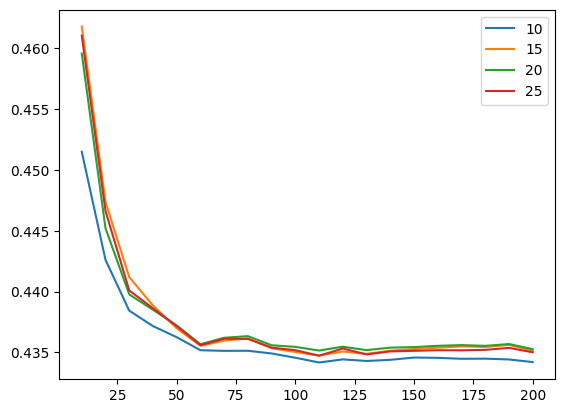

In [27]:
for d in [10, 15, 20, 25]:
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.rmse, label=d)

plt.legend()
plt.show()

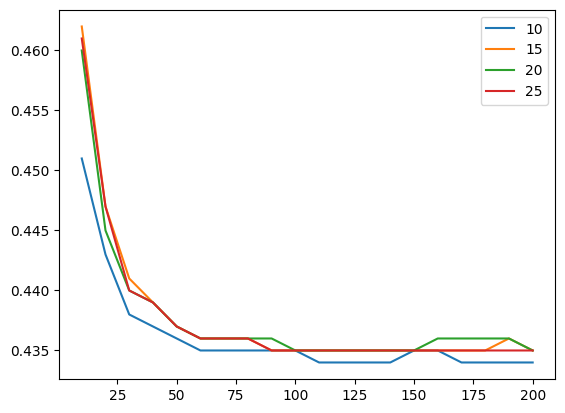

In [28]:
for d in [10, 15, 20, 25]:
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_estimators, df_subset.rmse.round(3), label=d)

plt.legend()
plt.show()

In [32]:
df_scores.head(20)

,max_depth,n_estimators,rmse
0,10,10,0.451500
1,10,20,0.442613
2,10,30,0.438437
3,10,40,0.437166
4,10,50,0.436255
5,10,60,0.435184
6,10,70,0.435132
7,10,80,0.435138
8,10,90,0.434918
9,10,100,0.434566


In [31]:
mean_rmse_by_depth = df_scores.groupby('max_depth').rmse.mean()
print(mean_rmse_by_depth)

max_depth
10    0.436247
15    0.437825
20    0.437693
25    0.437653
Name: rmse, dtype: float64


Answer Q4: from these results, we can see that max_depth=10 has the lowest mean RMSE (0.436472).

# Question 5

We can extract feature importance information from tree-based models. 

At each step of the decision tree learning algorithm, it finds the best split. 
When doing it, we can calculate "gain" - the reduction in impurity before and after the split. 
This gain is quite useful in understanding what are the important features for tree-based models.

In Scikit-Learn, tree-based models contain this information in the
[`feature_importances_`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor.feature_importances_)
field. 

For this homework question, we'll find the most important feature:

* Train the model with these parameters:
  * `n_estimators=10`,
  * `max_depth=20`,
  * `random_state=1`,
  * `n_jobs=-1` (optional)
* Get the feature importance information from this model


What's the most important feature (among these 4)? 

* `vehicle_weight`
*	`horsepower`
* `acceleration`
* `engine_displacement`	


In [9]:
rf = RandomForestRegressor(
    n_estimators=10,
    max_depth=20,
    random_state=1,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=10, n_jobs=-1, random_state=1)

In [10]:
df_importances = pd.DataFrame()
df_importances['feature'] = dv.feature_names_
df_importances['importance'] = rf.feature_importances_
df_importances.sort_values(by='importance', ascending=False).head()

,feature,importance
13,vehicle_weight,0.959878
6,horsepower,0.015933
0,acceleration,0.011442
3,engine_displacement,0.003159
7,model_year,0.003066


Answer Q5: **vehicle_weight**

## Question 6

Now let's train an XGBoost model! For this question, we'll tune the `eta` parameter:

* Install XGBoost
* Create DMatrix for train and validation
* Create a watchlist
* Train a model with these parameters for 100 rounds:

```
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}
```

Now change `eta` from `0.3` to `0.1`.

Which eta leads to the best RMSE score on the validation dataset?

* 0.3
* 0.1
* Both give equal value

  Вам потрібно буде натренувати дві моделі XGBoost з різними значеннями параметра eta (0.3 та 0.1) і порівняти їхні показники RMSE на валідаційних даних.

  Ось кроки, які потрібно виконати:

  1. Встановіть XGBoost

  Якщо у вас ще не встановлена бібліотека XGBoost, відкрийте термінал і виконайте команду:

   1 pip install xgboost

  2. Підготуйте дані у форматі DMatrix

  XGBoost має власний формат даних, який називається DMatrix. Вам потрібно буде перетворити ваші тренувальні та валідаційні дані у цей формат. Не забудьте вказати
  feature_names, щоб XGBoost знав назви ваших ознак.

   1 import xgboost as xgb
   2 
   3 # dv - це ваш DictVectorizer з попередніх кроків
   4 feature_names = dv.feature_names_
   5 
   6 dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
   7 dval = xgb.DMatrix(X_val, label=y_val, feature_names=feature_names)

  3. Створіть watchlist

  watchlist дозволяє спостерігати за процесом навчання моделі на тренувальних та валідаційних даних на кожній ітерації.

   1 watchlist = [(dtrain, 'train'), (dval, 'val')]

  4. Натренуйте модель з eta=0.3

  Тепер натренуйте першу модель з параметром eta, встановленим на 0.3.

    1 xgb_params_1 = {
    2     'eta': 0.3,
    3     'max_depth': 6,
    4     'min_child_weight': 1,
    5     'objective': 'reg:squarederror',
    6     'nthread': 8,
    7     'seed': 1,
    8     'verbosity': 1,
    9 }
   10 
   11 model_1 = xgb.train(xgb_params_1, dtrain, num_boost_round=100, evals=watchlist, verbose_eval=10)
  verbose_eval=10 буде виводити RMSE кожні 10 ітерацій. Зверніть увагу на останнє значення RMSE для val.

  5. Натренуйте модель з eta=0.1

  Тепер змініть eta на 0.1 і натренуйте другу модель.

    1 xgb_params_2 = {
    2     'eta': 0.1,
    3     'max_depth': 6,
    4     'min_child_weight': 1,
    5     'objective': 'reg:squarederror',
    6     'nthread': 8,
    7     'seed': 1,
    8     'verbosity': 1,
    9 }
   10 
   11 model_2 = xgb.train(xgb_params_2, dtrain, num_boost_round=100, evals=watchlist, verbose_eval=10)
  Так само, подивіться на фінальне значення RMSE для val.

  6. Порівняйте результати

  Після тренування обох моделей, порівняйте їхні кінцеві показники RMSE на валідаційному наборі (val-rmse). Той eta, який дав менше значення RMSE, і буде відповіддю